# MNIST Digit Recognizer Project -- Upamanyu Moitra

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

## Loading and Pre-Processing Data

In [2]:
df = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")
df_test = pd.read_csv("/kaggle/input/digit-recognizer/test.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [4]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
y = df.iloc[:, 0].values
X = df.iloc[:, 1:].values
print("y info:", y.shape, y.dtype)
print("x info:", X.shape, X.dtype)

y info: (42000,) int64
x info: (42000, 784) int64


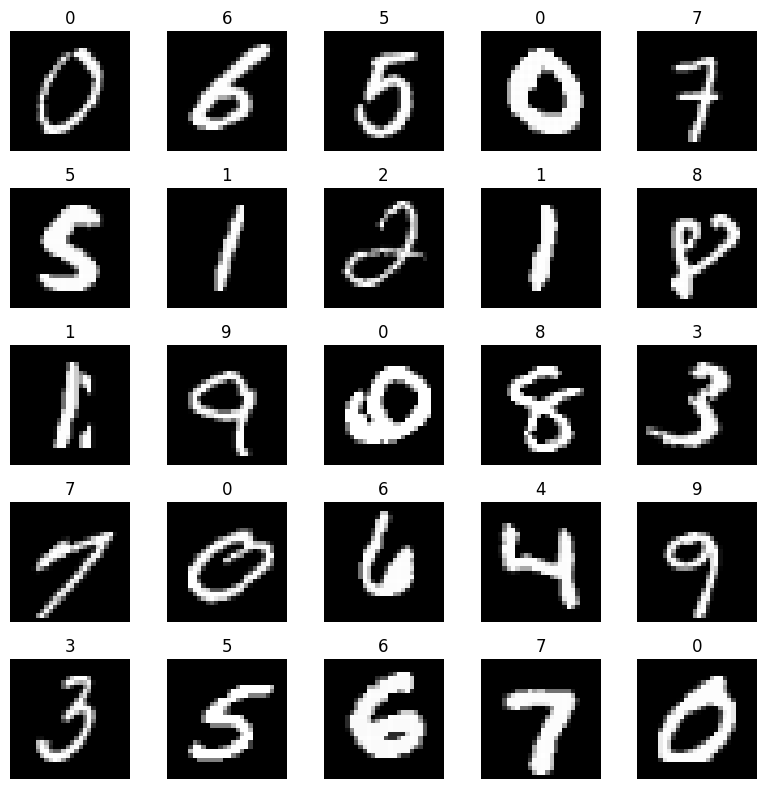

In [6]:
plt.figure(figsize = (8,8))
for i in range(25):
    index = np.random.randint(0, len(y))
    image = X[index].reshape(28,28)
    label = y[index]

    plt.subplot(5,5,i+1)
    plt.imshow(image, cmap = 'gray')
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
# Previous code Normaliztion of the X-values
X = X/255.0

##### Standard scaler does not really work well. Does min-max scaler work better?

In [8]:
#New code: standard scaler
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
X = sc.fit_transform(X)
print("X: shape and data type", X.shape, X.dtype)

X: shape and data type (42000, 784) float64


In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,\
                                                    random_state = 42, stratify = y)

### Preparation of Test Data

In [10]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Columns: 784 entries, pixel0 to pixel783
dtypes: int64(784)
memory usage: 167.5 MB


In [11]:
X_test_final = df_test.iloc[:,:].values
print("X_test_final size and type", X_test_final.shape, X_test_final.dtype)

X_test_final size and type (28000, 784) int64


In [12]:
X_test_final = sc.transform(X_test_final)
print("X_test_final type", X_test_final.dtype)

X_test_final type float64


In [13]:
import time

## Logistic Regression (Previous Accuracy 91.2%, After St Scaling: 90.23%, MinMaxScaling: 91.27%)

In [14]:
from sklearn.linear_model import LogisticRegression

In [15]:
%time clf = LogisticRegression(solver = 'lbfgs', max_iter = 1000, multi_class = 'multinomial')

CPU times: user 16 µs, sys: 2 µs, total: 18 µs
Wall time: 22.2 µs


In [16]:
%time clf.fit(X_train, y_train)

CPU times: user 5min 29s, sys: 276 ms, total: 5min 29s
Wall time: 1min 29s


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [17]:
from sklearn.metrics import accuracy_score, classification_report

In [18]:
y_pred_LR = clf.predict(X_test)
print(f"Accuracy {accuracy_score(y_test, y_pred_LR)}")
print(classification_report(y_test, y_pred_LR))

Accuracy 0.9127380952380952
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       827
           1       0.93      0.98      0.95       937
           2       0.91      0.90      0.91       835
           3       0.90      0.88      0.89       870
           4       0.92      0.91      0.91       814
           5       0.87      0.86      0.86       759
           6       0.95      0.96      0.96       827
           7       0.93      0.93      0.93       880
           8       0.88      0.85      0.87       813
           9       0.88      0.90      0.89       838

    accuracy                           0.91      8400
   macro avg       0.91      0.91      0.91      8400
weighted avg       0.91      0.91      0.91      8400



## K-Nearest Neighbor Classifier (Accuracy 96.67%, max reached with $n=3$, Standard Scaling: 93.80%, MinMax: 96.67%)

In [19]:
from sklearn.neighbors import KNeighborsClassifier

In [20]:
knn = KNeighborsClassifier(n_neighbors = 3, p = 2, metric = 'minkowski' )
%time knn.fit(X_train, y_train)

CPU times: user 33.3 ms, sys: 995 µs, total: 34.3 ms
Wall time: 31.7 ms


KNeighborsClassifier(n_neighbors=3)

In [21]:
%time y_pred_KNN = knn.predict(X_test)
print(f"KNN Accuracy {accuracy_score(y_test, y_pred_KNN)}")
print(classification_report(y_test, y_pred_KNN))

CPU times: user 30.3 s, sys: 35.6 ms, total: 30.3 s
Wall time: 8.33 s
KNN Accuracy 0.9666666666666667
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       827
           1       0.95      1.00      0.97       937
           2       0.98      0.96      0.97       835
           3       0.96      0.96      0.96       870
           4       0.98      0.96      0.97       814
           5       0.95      0.96      0.96       759
           6       0.98      0.99      0.99       827
           7       0.97      0.97      0.97       880
           8       0.99      0.90      0.94       813
           9       0.95      0.96      0.95       838

    accuracy                           0.97      8400
   macro avg       0.97      0.97      0.97      8400
weighted avg       0.97      0.97      0.97      8400



## Linear SVC (Accuracy 90.71%, StdScale Accuracy 89.92%, MinMax Accuracy: 90.67%)

In [22]:
from sklearn.svm import LinearSVC

In [23]:
lsvc = LinearSVC(random_state = 42, C = 1.0, max_iter = 1000)

In [24]:
%time lsvc.fit(X_train, y_train)

CPU times: user 1min 4s, sys: 77.1 ms, total: 1min 4s
Wall time: 1min 4s


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(random_state=42)

In [25]:
y_pred_LSVC = lsvc.predict(X_test)
print(f"LSVC Accuracy {accuracy_score(y_test, y_pred_LSVC)}")
print(classification_report(y_test, y_pred_LSVC))

LSVC Accuracy 0.9067857142857143
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       827
           1       0.94      0.98      0.96       937
           2       0.90      0.89      0.89       835
           3       0.88      0.88      0.88       870
           4       0.91      0.91      0.91       814
           5       0.86      0.84      0.85       759
           6       0.95      0.96      0.95       827
           7       0.92      0.93      0.92       880
           8       0.87      0.84      0.85       813
           9       0.87      0.87      0.87       838

    accuracy                           0.91      8400
   macro avg       0.91      0.91      0.91      8400
weighted avg       0.91      0.91      0.91      8400



## Naive Bayes Classifier (Naive and MinMax Accuracy 82.46%)

In [26]:
from sklearn.naive_bayes import MultinomialNB

In [27]:
nb = MultinomialNB()
%time nb.fit(X_train, y_train)

CPU times: user 130 ms, sys: 2.99 ms, total: 133 ms
Wall time: 104 ms


MultinomialNB()

In [28]:
%time y_pred_NB = nb.predict(X_test)
print(f"Naive Multinomial Bayes Accuracy {accuracy_score(y_test, y_pred_NB)}")
print(classification_report(y_test, y_pred_NB))

CPU times: user 30 ms, sys: 2 ms, total: 32 ms
Wall time: 16.9 ms
Naive Multinomial Bayes Accuracy 0.8246428571428571
              precision    recall  f1-score   support

           0       0.93      0.92      0.93       827
           1       0.89      0.93      0.91       937
           2       0.87      0.85      0.86       835
           3       0.80      0.81      0.80       870
           4       0.84      0.72      0.77       814
           5       0.84      0.64      0.73       759
           6       0.88      0.92      0.90       827
           7       0.96      0.83      0.89       880
           8       0.64      0.77      0.70       813
           9       0.68      0.84      0.75       838

    accuracy                           0.82      8400
   macro avg       0.83      0.82      0.82      8400
weighted avg       0.83      0.82      0.83      8400



## Random Forest Classifier (Naive scaling optimized at $n=140$, MinMax Optimized at $n=150$ with Accuracy 96.5 in Both Cases)

In [29]:
from sklearn.ensemble import RandomForestClassifier

In [30]:
forest = RandomForestClassifier(criterion='gini', n_estimators= 150, random_state=1, n_jobs=3)
%time forest.fit(X_train, y_train)

CPU times: user 44.6 s, sys: 229 ms, total: 44.8 s
Wall time: 15.1 s


RandomForestClassifier(n_estimators=150, n_jobs=3, random_state=1)

In [31]:
%time y_pred_forest = forest.predict(X_test)
print(f"Random Forest Accuracy {accuracy_score(y_test, y_pred_forest)}")
print(classification_report(y_test, y_pred_forest))

CPU times: user 720 ms, sys: 16 ms, total: 736 ms
Wall time: 265 ms
Random Forest Accuracy 0.965
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       827
           1       0.98      0.99      0.99       937
           2       0.96      0.97      0.96       835
           3       0.95      0.94      0.95       870
           4       0.97      0.97      0.97       814
           5       0.96      0.95      0.95       759
           6       0.97      0.99      0.98       827
           7       0.98      0.97      0.97       880
           8       0.95      0.95      0.95       813
           9       0.95      0.95      0.95       838

    accuracy                           0.96      8400
   macro avg       0.96      0.96      0.96      8400
weighted avg       0.96      0.96      0.96      8400



## Multi-Layer Perceptron with Various Configs

In [32]:
from sklearn.neural_network import MLPClassifier

In [33]:
mlp1 = MLPClassifier(hidden_layer_sizes = (300, 100),\
                    activation = 'relu',\
                    learning_rate = 'adaptive',\
                    random_state = 42,\
                    verbose = True,\
                    early_stopping = True)

In [34]:
%time mlp1.fit(X_train, y_train)

Iteration 1, loss = 0.43294992
Validation score: 0.934226
Iteration 2, loss = 0.15717502
Validation score: 0.950595
Iteration 3, loss = 0.10722676
Validation score: 0.957738
Iteration 4, loss = 0.07371407
Validation score: 0.965476
Iteration 5, loss = 0.05447606
Validation score: 0.964286
Iteration 6, loss = 0.04052355
Validation score: 0.969345
Iteration 7, loss = 0.03113200
Validation score: 0.972321
Iteration 8, loss = 0.02576814
Validation score: 0.971726
Iteration 9, loss = 0.01793343
Validation score: 0.972024
Iteration 10, loss = 0.01300706
Validation score: 0.974107
Iteration 11, loss = 0.00893569
Validation score: 0.974702
Iteration 12, loss = 0.00592511
Validation score: 0.968750
Iteration 13, loss = 0.00572077
Validation score: 0.972321
Iteration 14, loss = 0.00432992
Validation score: 0.972917
Iteration 15, loss = 0.00368790
Validation score: 0.973512
Iteration 16, loss = 0.00220507
Validation score: 0.975000
Iteration 17, loss = 0.00170168
Validation score: 0.975298
Iterat

MLPClassifier(early_stopping=True, hidden_layer_sizes=(300, 100),
              learning_rate='adaptive', random_state=42, verbose=True)

In [35]:
y_pred_mlp1 = mlp1.predict(X_test)
print(f"First MLP Accuracy {accuracy_score(y_test, y_pred_mlp1)}")
print(classification_report(y_test, y_pred_mlp1))

First MLP Accuracy 0.9779761904761904
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       827
           1       0.98      0.99      0.99       937
           2       0.98      0.98      0.98       835
           3       0.98      0.97      0.97       870
           4       0.99      0.98      0.98       814
           5       0.97      0.96      0.97       759
           6       0.99      0.99      0.99       827
           7       0.98      0.98      0.98       880
           8       0.98      0.97      0.97       813
           9       0.95      0.97      0.96       838

    accuracy                           0.98      8400
   macro avg       0.98      0.98      0.98      8400
weighted avg       0.98      0.98      0.98      8400



In [36]:
mlp2 = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),\
    activation='relu',\
    learning_rate='adaptive',\
    early_stopping=True,\
    batch_size=256,\
    verbose = True,\
    random_state=42)

In [37]:
%time mlp2.fit(X_train, y_train)

Iteration 1, loss = 0.38784304
Validation score: 0.935714
Iteration 2, loss = 0.13376684
Validation score: 0.961310
Iteration 3, loss = 0.08294474
Validation score: 0.970238
Iteration 4, loss = 0.05568373
Validation score: 0.969940
Iteration 5, loss = 0.03486135
Validation score: 0.975000
Iteration 6, loss = 0.02928464
Validation score: 0.971429
Iteration 7, loss = 0.02029744
Validation score: 0.968155
Iteration 8, loss = 0.01591046
Validation score: 0.975298
Iteration 9, loss = 0.01544146
Validation score: 0.975298
Iteration 10, loss = 0.00744482
Validation score: 0.978571
Iteration 11, loss = 0.00489747
Validation score: 0.979762
Iteration 12, loss = 0.00358533
Validation score: 0.976190
Iteration 13, loss = 0.00675785
Validation score: 0.965476
Iteration 14, loss = 0.02706764
Validation score: 0.974107
Iteration 15, loss = 0.01842657
Validation score: 0.968155
Iteration 16, loss = 0.01393825
Validation score: 0.973810
Iteration 17, loss = 0.01015198
Validation score: 0.976190
Iterat

MLPClassifier(batch_size=256, early_stopping=True,
              hidden_layer_sizes=(512, 256, 128), learning_rate='adaptive',
              random_state=42, verbose=True)

In [38]:
y_pred_mlp2 = mlp2.predict(X_test)
print(f"Second MLP Accuracy {accuracy_score(y_test, y_pred_mlp2)}")
print(classification_report(y_test, y_pred_mlp2))

Second MLP Accuracy 0.9798809523809524
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       827
           1       0.99      1.00      0.99       937
           2       0.99      0.98      0.98       835
           3       0.98      0.97      0.97       870
           4       0.98      0.98      0.98       814
           5       0.97      0.96      0.97       759
           6       0.99      0.99      0.99       827
           7       0.98      0.98      0.98       880
           8       0.98      0.97      0.97       813
           9       0.96      0.97      0.96       838

    accuracy                           0.98      8400
   macro avg       0.98      0.98      0.98      8400
weighted avg       0.98      0.98      0.98      8400



In a version, now deleted, the Standard Scaler was shown to work worse. /255 scaling is the best apparently. So I am going to stick with that in the next one

# Final Result

In [39]:
X_test_final = df_test.iloc[:,:].values
X_test_final = X_test_final/255.0
X = df.iloc[:, 1:].values
X = X/255.0
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,\
                                                    random_state = 42, stratify = y)

In [40]:
mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),\
    activation='relu',\
    learning_rate='adaptive',\
    early_stopping=True,\
    batch_size=256,\
    verbose = True,\
    random_state=42)

In [41]:
%time mlp.fit(X_train, y_train)

Iteration 1, loss = 0.38854967
Validation score: 0.936012
Iteration 2, loss = 0.13411903
Validation score: 0.960714
Iteration 3, loss = 0.08248166
Validation score: 0.968750
Iteration 4, loss = 0.05619850
Validation score: 0.972024
Iteration 5, loss = 0.03508098
Validation score: 0.976488
Iteration 6, loss = 0.02812095
Validation score: 0.969345
Iteration 7, loss = 0.02344849
Validation score: 0.973810
Iteration 8, loss = 0.01779268
Validation score: 0.978274
Iteration 9, loss = 0.01196562
Validation score: 0.977976
Iteration 10, loss = 0.00796068
Validation score: 0.977083
Iteration 11, loss = 0.00476388
Validation score: 0.980357
Iteration 12, loss = 0.01687487
Validation score: 0.972619
Iteration 13, loss = 0.01474196
Validation score: 0.975893
Iteration 14, loss = 0.00437892
Validation score: 0.975893
Iteration 15, loss = 0.00849653
Validation score: 0.973214
Iteration 16, loss = 0.01715700
Validation score: 0.972024
Iteration 17, loss = 0.01414303
Validation score: 0.972321
Iterat

MLPClassifier(batch_size=256, early_stopping=True,
              hidden_layer_sizes=(512, 256, 128), learning_rate='adaptive',
              random_state=42, verbose=True)

In [42]:
y_pred_mlp = mlp.predict(X_test)
print(f"Final MLP Accuracy {accuracy_score(y_test, y_pred_mlp)}")
print(classification_report(y_test, y_pred_mlp))

Final MLP Accuracy 0.9782142857142857
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       827
           1       0.99      0.99      0.99       937
           2       0.98      0.98      0.98       835
           3       0.98      0.97      0.97       870
           4       0.98      0.98      0.98       814
           5       0.96      0.97      0.97       759
           6       0.99      0.99      0.99       827
           7       0.98      0.98      0.98       880
           8       0.98      0.97      0.97       813
           9       0.96      0.97      0.96       838

    accuracy                           0.98      8400
   macro avg       0.98      0.98      0.98      8400
weighted avg       0.98      0.98      0.98      8400



It appears that MLP2 was the best classifier with MinMax Scaler. So I have to go back to that.

In [43]:
X = df.iloc[:, 1:].values
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
X = sc.fit_transform(X)
X_test_final = df_test.iloc[:,:].values
X_test_final = sc.transform(X_test_final)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,\
                                                    random_state = 42, stratify = y)

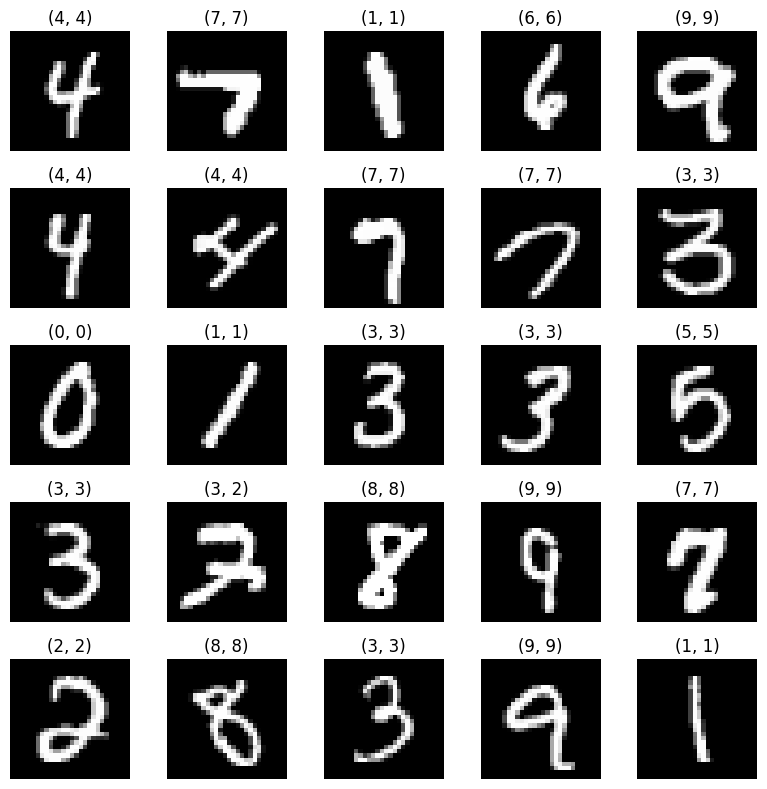

In [44]:
plt.figure(figsize = (8,8))
for i in range(25):
    index = np.random.randint(0, len(y_pred_mlp2))
    image = sc.inverse_transform(X_test[index].reshape(1,-1)).reshape(28,28)
    label = y_test[index], y_pred_mlp2[index]

    plt.subplot(5,5,i+1)
    plt.imshow(image, cmap = 'gray')
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [45]:
y_final_pred = mlp2.predict(X_test_final)

In [46]:
y_final_pred.shape

(28000,)

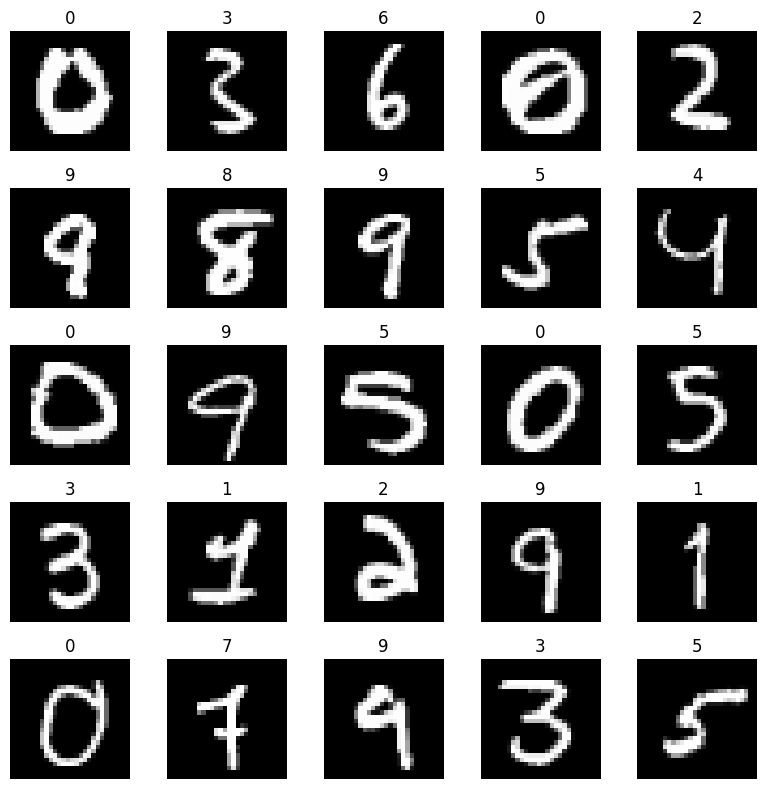

In [47]:
plt.figure(figsize = (8,8))
for i in range(25):
    index = np.random.randint(0, len(y_final_pred))
    image = sc.inverse_transform(X_test_final[index].reshape(1,-1)).reshape(28,28)
    label = y_final_pred[index]

    plt.subplot(5,5,i+1)
    plt.imshow(image, cmap = 'gray')
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [48]:
submission_csv = pd.read_csv("/kaggle/input/digit-recognizer/sample_submission.csv")

In [49]:
submission_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   ImageId  28000 non-null  int64
 1   Label    28000 non-null  int64
dtypes: int64(2)
memory usage: 437.6 KB


In [50]:
submission_csv.head()

,ImageId,Label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [51]:
submission_csv['Label'] = y_final_pred

In [52]:
submission_csv.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3


In [53]:
submission_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   ImageId  28000 non-null  int64
 1   Label    28000 non-null  int64
dtypes: int64(2)
memory usage: 437.6 KB


In [54]:
submission_csv.to_csv("submission.csv", index=False)